# 02 · Análisis de las puntuaciones

Se estudian content y wording a partir de las copias limpias del notebook 01. La primera variable evalúa el contenido del resumen y la segunda su redacción. Se busca describir su distribución, revisar valores extremos y conocer cómo se relacionan.

Se conservan todas las observaciones. Los valores negativos no se tratan como errores y los puntos extremos se marcan para revisión sin borrarlos. Este análisis usa únicamente los datos de entrenamiento.

## 1. Preparación y continuidad de los datos

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = next(
    (path for path in [Path.cwd(), *Path.cwd().parents]
     if (path / "src").is_dir() and (path / "notebooks").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("No se encontró la raíz del proyecto.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_csv_files

INTERIM_DATA_DIR = PROJECT_ROOT / "data" / "interim"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
for directory in [TABLES_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

clean_files = ["summaries_train_clean.csv", "prompts_train_clean.csv"]
if not all((INTERIM_DATA_DIR / name).is_file() for name in clean_files):
    raise FileNotFoundError(
        "Faltan las copias limpias. Ejecute primero 00_data_loading.ipynb "
        "y 01_data_quality.ipynb con los CSV de entrenamiento en data/raw/."
    )
datasets = load_csv_files(INTERIM_DATA_DIR, clean_files)
summaries = datasets["summaries_train_clean"]
prompts = datasets["prompts_train_clean"]
assert not summaries.empty, "No hay resúmenes para analizar."
assert summaries["student_id"].notna().all() and summaries["student_id"].is_unique
assert prompts["prompt_id"].notna().all() and prompts["prompt_id"].is_unique
assert summaries["prompt_id"].notna().all()
assert summaries["prompt_id"].isin(prompts["prompt_id"]).all()
plt.rcParams.update({"figure.figsize": [10, 4], "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})

In [2]:
target_columns = ["content", "wording"]
target_checks = pd.DataFrame({
    "faltantes": summaries[target_columns].isna().sum(),
    "no_finitos_sin_contar_faltantes": [
        int((summaries[column].notna() & ~np.isfinite(summaries[column])).sum())
        for column in target_columns
    ],
})
display(target_checks)
target_checks.to_csv(TABLES_DIR / "02_target_checks.csv", index_label="variable")
if target_checks.to_numpy().sum():
    raise ValueError("Hay puntuaciones faltantes o no finitas. Revise el notebook 01.")
targets = summaries[target_columns].copy()
print(f"Se analizan {len(targets):,} resúmenes y {summaries['prompt_id'].nunique()} prompts.")

,faltantes,no_finitos_sin_contar_faltantes
content,0,0
wording,0,0


Se analizan 7,165 resúmenes y 4 prompts.


## 2. Estadística descriptiva

La media y la mediana muestran el centro de cada distribución. La desviación estándar y el rango intercuartílico describen su dispersión. Los percentiles 1 y 99 ayudan a revisar los extremos. La asimetría positiva indica una cola hacia valores altos y la negativa una cola hacia valores bajos.

In [3]:
description = targets.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T
description["iqr"] = description["75%"] - description["25%"]
description["asimetría"] = targets.skew()
display(description.round(4))
description.to_csv(TABLES_DIR / "02_target_descriptive.csv", index_label="variable")
for column in target_columns:
    row = description.loc[column]
    print(f"{column}: media {row['mean']:.3f}, mediana {row['50%']:.3f} "
          f"y desviación estándar {row['std']:.3f}. "
          f"La mitad central se encuentra entre {row['25%']:.3f} y {row['75%']:.3f}.")

,count,mean,std,min,1%,25%,50%,75%,99%,max,iqr,asimetría
content,7165.0,-0.0149,1.0436,-1.7299,-1.5472,-0.7995,-0.0938,0.4997,2.9417,3.9003,1.2992,0.7261
wording,7165.0,-0.0631,1.0360,-1.9626,-1.7955,-0.8727,-0.0818,0.5038,2.7332,4.3107,1.3766,0.5650


content: media -0.015, mediana -0.094 y desviación estándar 1.044. La mitad central se encuentra entre -0.800 y 0.500.
wording: media -0.063, mediana -0.082 y desviación estándar 1.036. La mitad central se encuentra entre -0.873 y 0.504.


## 3. Distribuciones

Los histogramas usan los mismos intervalos para facilitar la comparación. Las líneas ubican la media y la mediana. Los diagramas de caja muestran la mitad central de los datos y marcan los puntos fuera de los límites de 1.5 veces el rango intercuartílico. Estas marcas no prueban que un dato sea incorrecto.

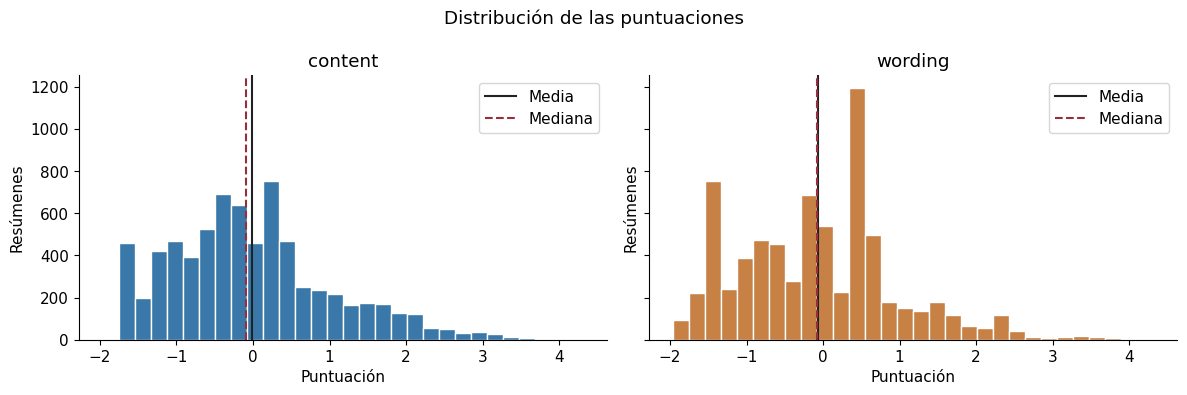

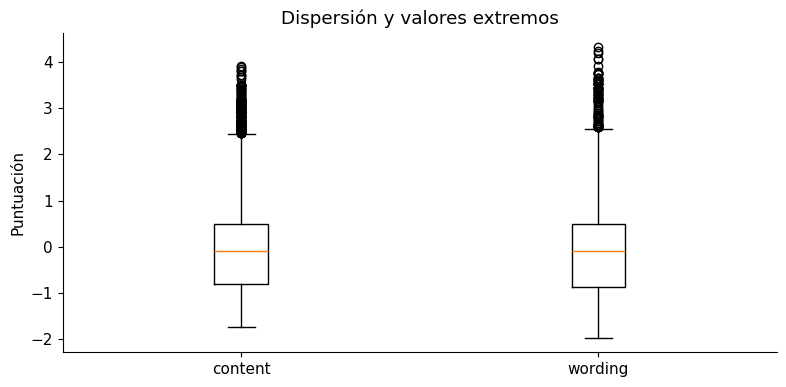

In [4]:
bins = np.histogram_bin_edges(targets.to_numpy().ravel(), bins=30)
fig, axes = plt.subplots(1, 2, figsize=[12, 4], sharex=True, sharey=True)
for ax, column, color in zip(axes, target_columns, ["#3978a8", "#c78145"]):
    ax.hist(targets[column], bins=bins, color=color, edgecolor="white")
    ax.axvline(targets[column].mean(), color="#222222", label="Media")
    ax.axvline(targets[column].median(), color="#972e3b", linestyle="--", label="Mediana")
    ax.set(title=column, xlabel="Puntuación", ylabel="Resúmenes")
    ax.legend()
fig.suptitle("Distribución de las puntuaciones")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_target_histograms.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=[8, 4])
ax.boxplot([targets[column] for column in target_columns])
ax.set_xticks([1, 2], target_columns)
ax.set(title="Dispersión y valores extremos", ylabel="Puntuación")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_target_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Revisión de valores extremos

Se marca un valor cuando queda por debajo del primer cuartil menos 1.5 veces el rango intercuartílico o por encima del tercer cuartil más 1.5 veces ese rango. Se cuentan los casos por variable y los resúmenes marcados en al menos una variable, para evitar contar dos veces el mismo resumen.

Las puntuaciones extremas pueden corresponder a desempeños poco frecuentes. Se muestran ejemplos con su texto para revisar su contexto. Se mantienen en el análisis, como se decidió en el notebook 01.

In [5]:
outlier_flags = pd.DataFrame(index=summaries.index)
outlier_rows = []
for column in target_columns:
    q1, q3 = targets[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    below = targets[column] < lower
    above = targets[column] > upper
    outlier_flags[column] = below | above
    outlier_rows.append({"variable": column, "límite_inferior": lower,
                         "límite_superior": upper, "bajos": int(below.sum()),
                         "altos": int(above.sum()), "total": int((below | above).sum()),
                         "porcentaje": 100 * (below | above).mean()})
outlier_report = pd.DataFrame(outlier_rows).set_index("variable")
display(outlier_report.round(4))
outlier_report.to_csv(TABLES_DIR / "02_target_outliers.csv", index_label="variable")
flagged = summaries[["student_id", "prompt_id", "content", "wording"]].copy()
for column in target_columns:
    flagged[f"outlier_{column}"] = outlier_flags[column]
flagged.to_csv(TABLES_DIR / "02_target_outlier_flags.csv", index=False)
print(f"Resúmenes extremos en al menos una variable: {outlier_flags.any(axis=1).sum():,}.")
extreme_indices = pd.Index([])
for column in target_columns:
    extreme_indices = extreme_indices.union(targets[column].nsmallest(2).index)
    extreme_indices = extreme_indices.union(targets[column].nlargest(2).index)
with pd.option_context("display.max_colwidth", 180):
    display(summaries.loc[extreme_indices, ["student_id", "prompt_id", "text", *target_columns]])

,límite_inferior,límite_superior,bajos,altos,total,porcentaje
variable,,,,,,
content,-2.7484,2.4485,0,170,170,2.3726
wording,-2.9375,2.5687,0,87,87,1.2142


Resúmenes extremos en al menos una variable: 200.


,student_id,prompt_id,text,content,wording
2,004e978e639e,3b9047,"In Egypt, there were many occupations and social classes involved in day-to-day living. In many instances if you were at the bottom of the social ladder you could climb up, you...",3.128928,4.231226
23,00dccd666d09,ebad26,"Since it was the custom, whenever meat was so spoiled that it could not be used for anything else, either to can it or else to chop it up into sausage. It was only when the who...",-0.382272,-1.795491
1970,465735e2610e,39c16e,"The ideal tragedy should imitate actions that excite pity and fear. Pity is aroused by unmerited misfortune, fear by the misfortune of a man like ourselves. A well-constructed ...",0.200173,-1.962614
2414,563eeb57f8dd,3b9047,The structure of egyptans made a ruler called a pharaoh who had black people as slaves like racism pharaohs make its slaves build things such as pryamids and finding gold to me...,-1.729859,-0.362702
2597,5cfd71609cda,3b9047,"The ancient Egyptian system of government was shaped like a pyramid. At the top, the pharaoh was believed to be the human form of a god. He would enact laws, collect taxes, and...",3.894070,2.965560
2706,60839fab23ed,814d6b,History Teacher Ron Jones couldn't control his class so he wanted to find a way to keep his students from misbehaving and to start socializing and he created The Third Wave to ...,-1.729859,-0.362702
5035,b257979693a2,814d6b,"Ron Jones gave the students little by little what they needed to begin growing the movement. He first began the movement, and did not tell them it was an experiment. He then ma...",3.112381,4.310693
5641,c8c77fd9fb07,39c16e,"As described by Aristotle, three elements of an ideal tragedy would be that the plot should feature the downfall of a man who is not completely evil but who has a flaw which ca...",3.900326,0.556480


## 5. Relación entre content y wording

Pearson resume la relación lineal. Spearman compara el orden de las puntuaciones y permite observar si ambas tienden a subir juntas aunque la relación no sea lineal. Se calcula Spearman como la correlación de los rangos, usando el rango promedio para los empates.

El gráfico diferencia los prompts porque la relación global puede estar influida por la mezcla de textos de origen. Se incluyen las correlaciones dentro de cada prompt como control. Una correlación no demuestra causalidad y una correlación indefinida se conserva como valor faltante cuando no hay variación suficiente.

,Pearson,Spearman
content y wording,0.7514,0.7124


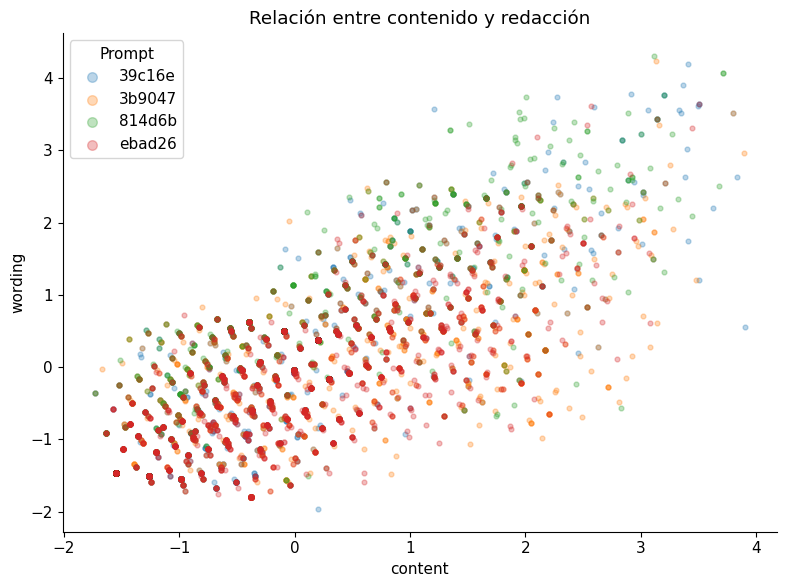

,prompt_id,resúmenes,Pearson,Spearman
0,39c16e,2057,0.8129,0.7564
1,3b9047,2009,0.6875,0.6695
2,814d6b,1103,0.8138,0.7757
3,ebad26,1996,0.7534,0.7217


In [6]:
pearson = targets.corr()
spearman = targets.rank(method="average").corr()
correlations = pd.DataFrame({"Pearson": [pearson.loc["content", "wording"]],
                             "Spearman": [spearman.loc["content", "wording"]]},
                            index=["content y wording"])
display(correlations.round(4))
correlations.to_csv(TABLES_DIR / "02_target_correlations.csv", index_label="relación")

group_rows = []
fig, ax = plt.subplots(figsize=[8, 6])
for prompt_id, group in summaries.groupby("prompt_id", sort=True):
    ax.scatter(group["content"], group["wording"], s=12, alpha=0.3, label=str(prompt_id))
    pair = group[target_columns]
    group_rows.append({"prompt_id": prompt_id, "resúmenes": len(group),
                       "Pearson": pair.corr().loc["content", "wording"],
                       "Spearman": pair.rank().corr().loc["content", "wording"]})
ax.set(title="Relación entre contenido y redacción", xlabel="content", ylabel="wording")
ax.legend(title="Prompt", markerscale=2)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_target_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
group_correlations = pd.DataFrame(group_rows)
display(group_correlations.round(4))
group_correlations.to_csv(TABLES_DIR / "02_target_correlations_by_prompt.csv", index=False)

## 6. Hallazgos del análisis

El siguiente resumen se calcula con los datos cargados. Los puntos marcados por el criterio intercuartílico se conservan y no se imputan puntuaciones. La comparación detallada entre prompts continúa en el notebook 04 y la relación con las características del texto en el notebook 03.

In [7]:
for column in target_columns:
    row = description.loc[column]
    outliers = outlier_report.loc[column]
    tail = "hacia valores altos" if row["asimetría"] > 0 else "hacia valores bajos" if row["asimetría"] < 0 else "sin asimetría"
    print(f"{column} tiene una media de {row['mean']:.3f} y una mediana de {row['50%']:.3f}. "
          f"La asimetría es {row['asimetría']:.3f}, {tail}. "
          f"El criterio intercuartílico marca {int(outliers['total']):,} resúmenes, "
          f"equivalentes al {outliers['porcentaje']:.2f} %.")
r = correlations.iloc[0]
print(f"La correlación global es {r['Pearson']:.3f} con Pearson y {r['Spearman']:.3f} con Spearman.")
within = group_correlations["Pearson"].dropna()
if not within.empty:
    print(f"Dentro de los prompts, Pearson va de {within.min():.3f} a {within.max():.3f}. "
          "La relación global debe leerse junto con estas diferencias.")
print("Los valores extremos requieren revisar el resumen y su texto de origen antes de tomar decisiones de limpieza.")
print("El siguiente paso es estudiar si las características del texto se relacionan con ambas puntuaciones.")

content tiene una media de -0.015 y una mediana de -0.094. La asimetría es 0.726, hacia valores altos. El criterio intercuartílico marca 170 resúmenes, equivalentes al 2.37 %.
wording tiene una media de -0.063 y una mediana de -0.082. La asimetría es 0.565, hacia valores altos. El criterio intercuartílico marca 87 resúmenes, equivalentes al 1.21 %.
La correlación global es 0.751 con Pearson y 0.712 con Spearman.
Dentro de los prompts, Pearson va de 0.687 a 0.814. La relación global debe leerse junto con estas diferencias.
Los valores extremos requieren revisar el resumen y su texto de origen antes de tomar decisiones de limpieza.
El siguiente paso es estudiar si las características del texto se relacionan con ambas puntuaciones.


### Interpretación de los resultados

En los 7,165 resúmenes, content tiene una media de -0.015 y wording de -0.063. Las desviaciones estándar son parecidas, de 1.044 y 1.036. Ambas distribuciones tienen una cola hacia las puntuaciones altas, más marcada en content. Los histogramas muestran varios picos, por lo que la media por sí sola no describe toda la distribución.

Se identifican 170 valores extremos en content y 87 en wording. Todos están por encima del límite superior. En total son 200 resúmenes distintos, ya que 57 aparecen en ambos grupos. Esto es consistente con las colas hacia valores altos. El criterio estadístico no demuestra un error en las puntuaciones y se mantienen todos los registros.

La correlación de Pearson es 0.751 y la de Spearman es 0.712. Los resúmenes con mayor puntuación de contenido tienden a tener mayor puntuación de redacción, aunque la dispersión muestra que ambas medidas no son equivalentes. La relación también es positiva dentro de los cuatro prompts, con Pearson entre 0.687 y 0.814. Por eso, la tendencia global no depende únicamente de mezclar los prompts.

No se encontraron puntuaciones faltantes ni no finitas. Los siguientes análisis pueden conservar las dos variables y revisar cómo se relacionan con las características del texto. Las diferencias entre prompts deben considerarse al comparar resultados, sin atribuirles una causa solo con estas correlaciones.